In [ ]:
import os
import time
import math
import tracemalloc
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import efficient_apriori

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

BASE_DIR = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Ingesta y exploracion

In [ ]:
csv_path = "bread basket.csv"
df_raw = pd.read_csv(csv_path)

print(f"Dimensiones del dataset: {df_raw.shape[0]}x{df_raw.shape[1]}\n")
print(df_raw.head(), end="\n\n")

print(df_raw.info(), end="\n\n")

num_trans_raw = df_raw["Transaction"].nunique()
num_items_raw = df_raw["Item"].nunique()
print(f"Transacciones únicas: {num_trans_raw}", end="\n\n")
print(f"Articulos unicos catalogados: {num_items_raw}")

Dimensiones del dataset: 20507x5

   Transaction           Item         date_time period_day weekday_weekend
0            1          Bread  30-10-2016 09:58    morning         weekend
1            2   Scandinavian  30-10-2016 10:05    morning         weekend
2            2   Scandinavian  30-10-2016 10:05    morning         weekend
3            3  Hot chocolate  30-10-2016 10:07    morning         weekend
4            3            Jam  30-10-2016 10:07    morning         weekend

<class 'pandas.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Transaction      20507 non-null  int64
 1   Item             20507 non-null  str  
 2   date_time        20507 non-null  str  
 3   period_day       20507 non-null  str  
 4   weekday_weekend  20507 non-null  str  
dtypes: int64(1), str(4)
memory usage: 801.2 KB
None

Transacciones únicas: 9465

Articulos unicos catalogados

### 1.1 Exploracion de los datos segun el tiempo
Vamos a analizar las transacciones segun el periodo del dia (period_day), tipo de dia (laboral o fin de semana) y  y el rango el rango de fechas

Rango de fechas: del 2016-10-30 09:58:00 al 2017-04-09 15:04:00


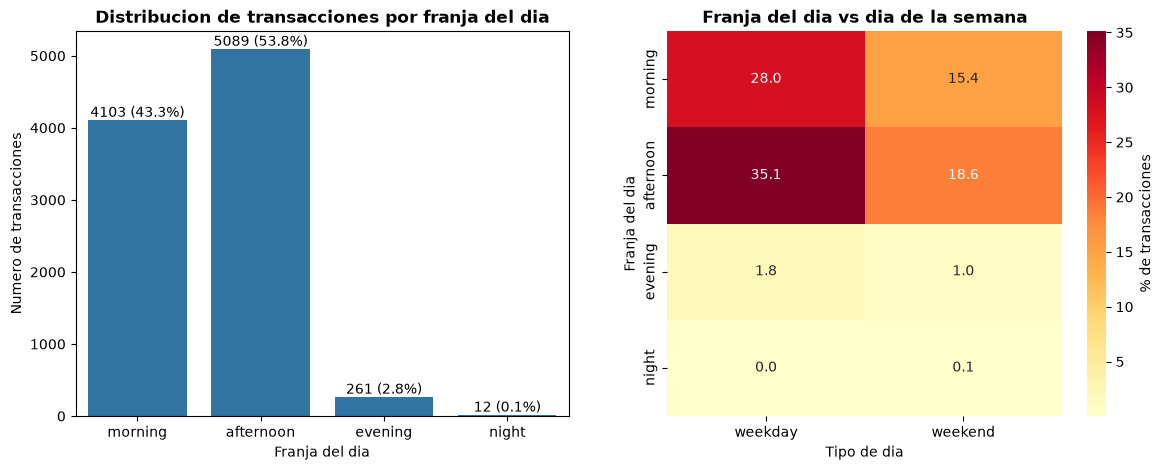

In [ ]:
df_raw["datetime_parsed"] = pd.to_datetime(df_raw["date_time"], format="%d-%m-%Y %H:%M")
df_raw["hour"] = df_raw["datetime_parsed"].dt.hour
df_raw["day_name"] = df_raw["datetime_parsed"].dt.day_name()
df_raw["month_year"] = df_raw["datetime_parsed"].dt.to_period("M")

print(
    f"Rango de fechas: del {df_raw['datetime_parsed'].min()} al {df_raw['datetime_parsed'].max()}"
)

df_trans_meta = df_raw.drop_duplicates(subset=["Transaction"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_period = ["morning", "afternoon", "evening", "night"]
period_counts = (
    df_trans_meta["period_day"].value_counts().reindex(order_period).dropna()
)
sns.barplot(x=period_counts.index, y=period_counts.values, ax=axes[0])
axes[0].set_title(
    "Distribucion de transacciones por franja del dia", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Franja del dia")
axes[0].set_ylabel("Numero de transacciones")
for i, v in enumerate(period_counts.values):
    axes[0].text(
        i, v + 50, f"{v} ({v / len(df_trans_meta):.1%})", ha="center", fontsize=10
    )

cross_temporal = (
    pd.crosstab(
        df_trans_meta["period_day"], df_trans_meta["weekday_weekend"], normalize="all"
    )
    * 100
)
sns.heatmap(
    cross_temporal.reindex(order_period),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=axes[1],
    cbar_kws={"label": "% de transacciones"},
)
axes[1].set_title("Franja del dia vs dia de la semana", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Tipo de dia")
axes[1].set_ylabel("Franja del dia")

plt.show()
plt.close()

### 1.2 Frecuencia de articulos y tamaño de cestas

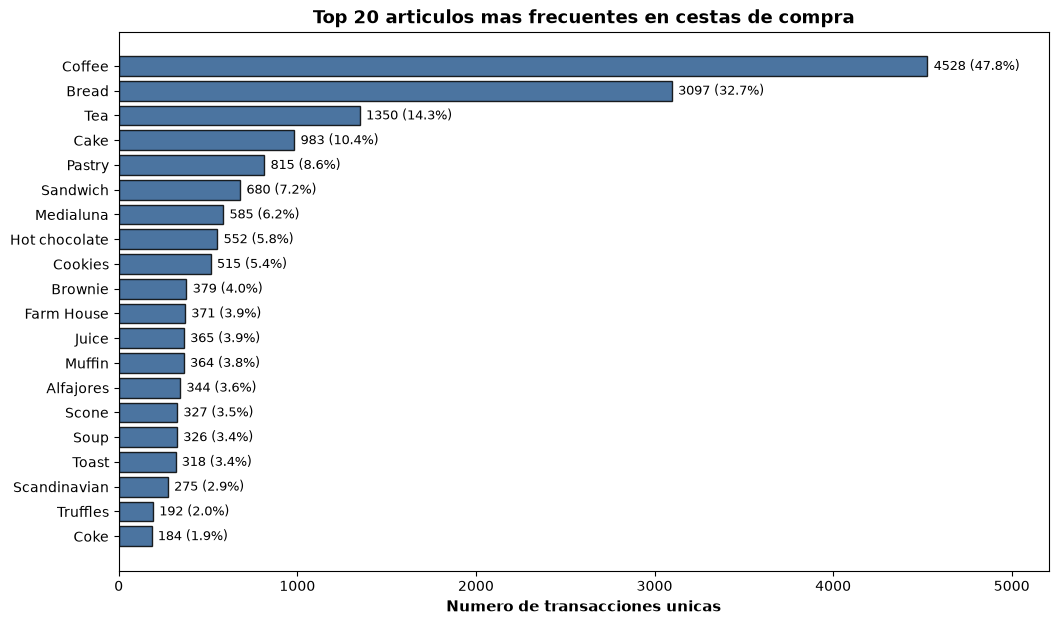

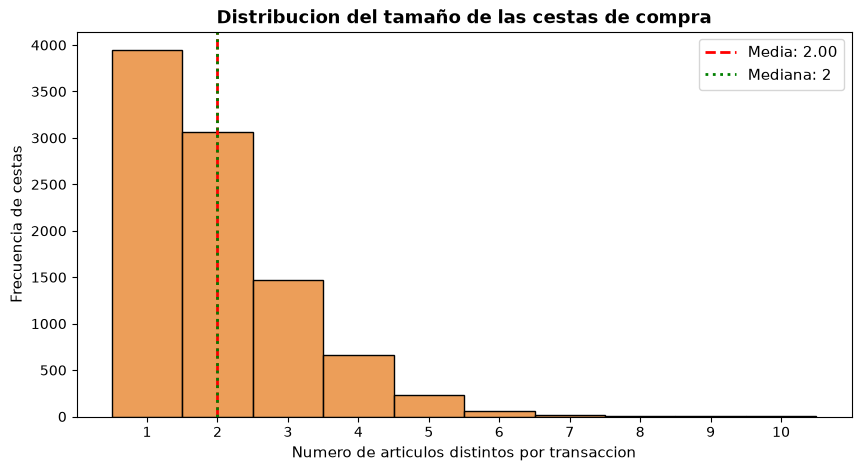

Resumen del tamaño de cesta:
Media: 2.00 | Mediana: 2.0 | Min: 1 | Max: 10
Cestas de 1 unico articulo: 3948 (41.7%)
Cestas de 2 o mas articulos: 5517 (58.3%)


In [ ]:
item_counts = (
    df_raw.groupby("Item")["Transaction"].nunique().sort_values(ascending=False)
)
top_20_items = item_counts.head(20)

plt.figure(figsize=(12, 7))
y_pos = np.arange(len(top_20_items))
bars = plt.barh(
    y_pos, top_20_items.values[::-1], color="#2b5c8f", edgecolor="black", alpha=0.85
)
plt.yticks(y_pos, top_20_items.index[::-1], fontsize=10)
plt.xlabel("Numero de transacciones unicas", fontsize=11, fontweight="bold")
plt.title(
    "Top 20 articulos mas frecuentes en cestas de compra",
    fontsize=13,
    fontweight="bold",
)

for bar in bars:
    w = bar.get_width()
    pct = (w / num_trans_raw) * 100
    plt.text(
        w + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{int(w)} ({pct:.1f}%)",
        va="center",
        fontsize=9,
    )

plt.xlim(0, max(top_20_items.values) * 1.15)
plt.show()
plt.close()

basket_sizes = df_raw.groupby("Transaction")["Item"].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    basket_sizes, discrete=True, kde=False, color="#e67e22", edgecolor="black", ax=ax
)
ax.set_title(
    "Distribucion del tamaño de las cestas de compra", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Numero de articulos distintos por transaccion", fontsize=11)
ax.set_ylabel("Frecuencia de cestas", fontsize=11)
ax.set_xticks(range(1, basket_sizes.max() + 1))

mean_size = basket_sizes.mean()
median_size = basket_sizes.median()
ax.axvline(
    mean_size, color="red", linestyle="--", linewidth=2, label=f"Media: {mean_size:.2f}"
)
ax.axvline(
    median_size,
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {median_size:.0f}",
)
ax.legend(fontsize=11)

plt.show()
plt.close()

print("Resumen del tamaño de cesta:")
print(
    f"Media: {mean_size:.2f} | Mediana: {median_size} | Min: {basket_sizes.min()} | Max: {basket_sizes.max()}"
)
print(
    f"Cestas de 1 unico articulo: {(basket_sizes == 1).sum()} ({(basket_sizes == 1).sum() / num_trans_raw:.1%})"
)
print(
    f"Cestas de 2 o mas articulos: {(basket_sizes >= 2).sum()} ({(basket_sizes >= 2).sum() / num_trans_raw:.1%})"
)

## 2. Preprocesamiento y modificacion del dataset
Quitamos los articulos que no son productos concretos: etiquetas de categoria (Keeping It Local, Hearty & Seasonal) y eventos (Afternoon with the baker, Argentina Night).
Una regla como Keeping It Local -> Coffee no dice que producto se compra, asi que no sirve para tomar decisiones.

In [ ]:
# Normalizacion de cadenas de texto
df_raw["Item"] = df_raw["Item"].astype(str).str.strip()

excluded_items = [
    "Keeping It Local",
    "Hearty & Seasonal",
    "Afternoon with the baker",
    "Argentina Night",
]
df_filtered = df_raw[~df_raw["Item"].isin(excluded_items)]
df_clean = df_filtered.drop_duplicates(subset=["Transaction", "Item"])

total_raw_rows = len(df_raw)
total_clean_rows = len(df_clean)
trans_clean = df_clean["Transaction"].nunique()
items_clean = df_clean["Item"].nunique()

print("Resumen de depuracion y preprocesamiento")
print(f"Filas originales: {total_raw_rows}")
print(f"Filas tras excluir {len(excluded_items)} articulos: {len(df_filtered)}")
print(
    f"Filas tras deduplicacion de compras multiples en la misma cesta: {total_clean_rows}"
)
print(
    f"Filas reducidas en total: {total_raw_rows - total_clean_rows} ({(total_raw_rows - total_clean_rows) / total_raw_rows:.2%})"
)
print(
    f"Transacciones resultantes: {trans_clean} (se pierden {num_trans_raw - trans_clean} que solo tenian articulos excluidos)"
)
print(f"Catalogo final de articulos: {items_clean}")

transactions_list = df_clean.groupby("Transaction")["Item"].apply(list).tolist()

Resumen de depuracion y preprocesamiento
Filas originales: 20507
Filas tras excluir 4 articulos: 20286
Filas tras deduplicacion de compras multiples en la misma cesta: 18674
Filas reducidas en total: 1833 (8.94%)
Transacciones resultantes: 9422 (se pierden 43 que solo tenian articulos excluidos)
Catalogo final de articulos: 90


In [ ]:
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
df_ohe = pd.DataFrame(te_ary, columns=te.columns_)

sparse_ohe_ary = te.fit(transactions_list).transform(transactions_list, sparse=True)
df_sparse = pd.DataFrame.sparse.from_spmatrix(sparse_ohe_ary, columns=te.columns_)

print(
    f"Formato OHE generado: {df_ohe.shape[0]} transacciones x {df_ohe.shape[1]} columnas (One-Hot Encoded)"
)
print(f"Uso de memoria OHE denso: {df_ohe.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Uso de memoria OHE sparse: {df_sparse.memory_usage().sum() / 1024**2:.2f} MB")


def build_tidsets(transactions):
    tidsets = defaultdict(set)
    for tid, tx in enumerate(transactions):
        for item in tx:
            tidsets[item].add(tid)
    return tidsets


tidsets_global = build_tidsets(transactions_list)
print(
    f"Estructura vertical TID-sets construida con éxito para {len(tidsets_global)} items."
)

Formato OHE generado: 9422 transacciones x 90 columnas (One-Hot Encoded)
Uso de memoria OHE denso: 0.81 MB
Uso de memoria OHE sparse: 0.09 MB
Estructura vertical TID-sets construida con éxito para 90 items.


## 3. Algoritmos para identificacion de reglas de asociacion: 
Apriori, FP-Growth y ECLAT

In [ ]:
def eclat(prefix, items, min_support, frequent_itemsets):
    """
    prefix: list of items forming the current prefix
    items: list of tuples (item, tidset) to consider for extension
    min_support: absolute minimum support (count)
    frequent_itemsets: dict to collect results {frozenset(itemset): support_count}
    """
    while items:
        item, tidset = items.pop()
        support = len(tidset)
        if support >= min_support:
            new_itemset = prefix + [item]
            frequent_itemsets[frozenset(new_itemset)] = support
            suffix = []
            for other_item, other_tidset in items:
                intersection = tidset & other_tidset
                if len(intersection) >= min_support:
                    suffix.append((other_item, intersection))
            suffix = sorted(suffix, key=lambda x: len(x[1]))
            eclat(new_itemset, suffix, min_support, frequent_itemsets)


def eclat_mining(tidsets, min_support, total_transactions):
    min_count = math.ceil(min_support * total_transactions - 1e-9)
    frequent_itemsets = {}
    initial_items = sorted(
        [(item, tids) for item, tids in tidsets.items() if len(tids) >= min_count],
        key=lambda x: len(x[1]),
    )
    eclat([], initial_items, min_count, frequent_itemsets)
    return pd.DataFrame(
        {
            "support": [c / total_transactions for c in frequent_itemsets.values()],
            "itemsets": list(frequent_itemsets.keys()),
        }
    )


def apriori_itemsets(transactions, min_support):
    itemsets_raw, _ = efficient_apriori.apriori(
        transactions, min_support=min_support, min_confidence=1.0, max_length=100
    )
    return pd.DataFrame(
        {
            "support": [
                count / len(transactions)
                for d in itemsets_raw.values()
                for count in d.values()
            ],
            "itemsets": [
                frozenset(items)
                for d in itemsets_raw.values()
                for items in d.keys()
            ],
        }
    )


for test_sup in [0.05, 0.02, 0.01, 0.005, 0.003, 0.002]:
    ap_test = apriori_itemsets(transactions_list, test_sup)
    fp_test = fpgrowth(df_ohe, min_support=test_sup, use_colnames=True)
    ec_test = eclat_mining(
        tidsets_global, min_support=test_sup, total_transactions=len(transactions_list)
    )

    set_ap = set(ap_test["itemsets"])
    set_fp = set(fp_test["itemsets"])
    set_ec = set(ec_test["itemsets"])

    print(
        f"min_support={test_sup:<6} | Apriori: {len(ap_test):4d} | FP-Growth: {len(fp_test):4d} | "
        f"ECLAT: {len(ec_test):4d} | Apriori==FP-Growth: {set_ap == set_fp!s:<5} | Apriori==ECLAT: {set_ap == set_ec!s:<5}"
    )

min_support=0.05   | Apriori:   12 | FP-Growth:   12 | ECLAT:   12 | Apriori==FP-Growth: True  | Apriori==ECLAT: True 
min_support=0.02   | Apriori:   33 | FP-Growth:   33 | ECLAT:   33 | Apriori==FP-Growth: True  | Apriori==ECLAT: True 
min_support=0.01   | Apriori:   60 | FP-Growth:   60 | ECLAT:   60 | Apriori==FP-Growth: True  | Apriori==ECLAT: True 
min_support=0.005  | Apriori:  110 | FP-Growth:  110 | ECLAT:  110 | Apriori==FP-Growth: True  | Apriori==ECLAT: True 
min_support=0.003  | Apriori:  172 | FP-Growth:  172 | ECLAT:  172 | Apriori==FP-Growth: True  | Apriori==ECLAT: True 
min_support=0.002  | Apriori:  252 | FP-Growth:  252 | ECLAT:  252 | Apriori==FP-Growth: True  | Apriori==ECLAT: True 


Como vemos, los 3 algoritmos dan los mismo resultados a todos los niveles de soporte

## 4. Benchmarking 
Cada ejecucion se repite varias veces para garantizar estabilidad y precision estadistica.

In [ ]:
def benchmark_algorithm(func, *args, repetitions=3, **kwargs):
    times = []
    peaks = []
    result = None

    for _ in range(repetitions):
        tracemalloc.start()
        t0 = time.perf_counter()
        result = func(*args, **kwargs)
        t1 = time.perf_counter()
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        times.append(t1 - t0)
        peaks.append(peak / (1024 * 1024))

    avg_time = np.mean(times)
    peak_mem = np.max(peaks)
    return result, avg_time, peak_mem


support_thresholds = [0.05, 0.03, 0.02, 0.015, 0.01, 0.007, 0.005, 0.003, 0.002]
bench_data = []

total_n_tx = len(transactions_list)

for sup in support_thresholds:
    # 1. Apriori
    res_ap, t_ap, m_ap = benchmark_algorithm(
        apriori_itemsets, transactions_list, min_support=sup
    )
    # 2. FP-Growth
    res_fp, t_fp, m_fp = benchmark_algorithm(
        fpgrowth, df_ohe, min_support=sup, use_colnames=True
    )
    # 3. ECLAT
    res_ec, t_ec, m_ec = benchmark_algorithm(
        eclat_mining, tidsets_global, min_support=sup, total_transactions=total_n_tx
    )

    n_itemsets = len(res_ap)

    bench_data.append(
        {
            "Support": sup,
            "Itemsets": n_itemsets,
            "Time_Apriori_s": t_ap,
            "Time_FPGrowth_s": t_fp,
            "Time_ECLAT_s": t_ec,
            "Mem_Apriori_MB": m_ap,
            "Mem_FPGrowth_MB": m_fp,
            "Mem_ECLAT_MB": m_ec,
        }
    )

bench_df = pd.DataFrame(bench_data)
print("Resultados del benchmark")
print(bench_df.to_string(index=False))

Resultados del benchmark
 Support  Itemsets  Time_Apriori_s  Time_FPGrowth_s  Time_ECLAT_s  Mem_Apriori_MB  Mem_FPGrowth_MB  Mem_ECLAT_MB
   0.050        12        0.006968         0.120042      0.001145        1.366240         0.075033      0.113373
   0.030        23        0.008762         0.123929      0.001931        1.462341         0.259308      0.201958
   0.020        33        0.009251         0.126027      0.002275        1.522713         0.307735      0.234077
   0.015        46        0.010300         0.126888      0.002980        1.581413         0.427305      0.274506
   0.010        60        0.011674         0.128759      0.003383        1.695557         0.524477      0.290489
   0.007        80        0.012980         0.128185      0.003810        1.790901         0.581011      0.302948
   0.005       110        0.014798         0.131170      0.004588        1.853653         0.661245      0.322517
   0.003       172        0.018881         0.133604      0.005504      

### 4.1 Visualizacion del benchmark

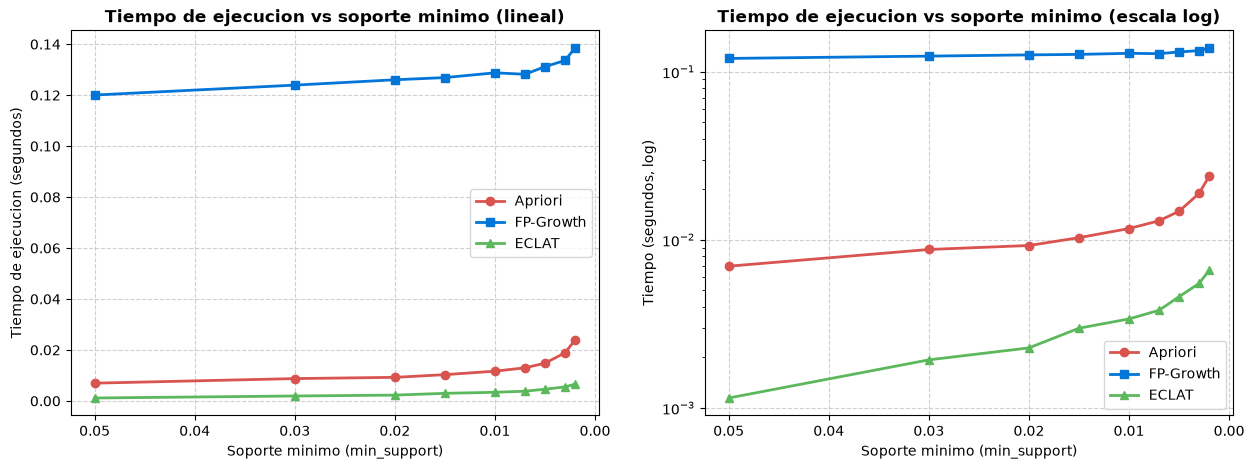

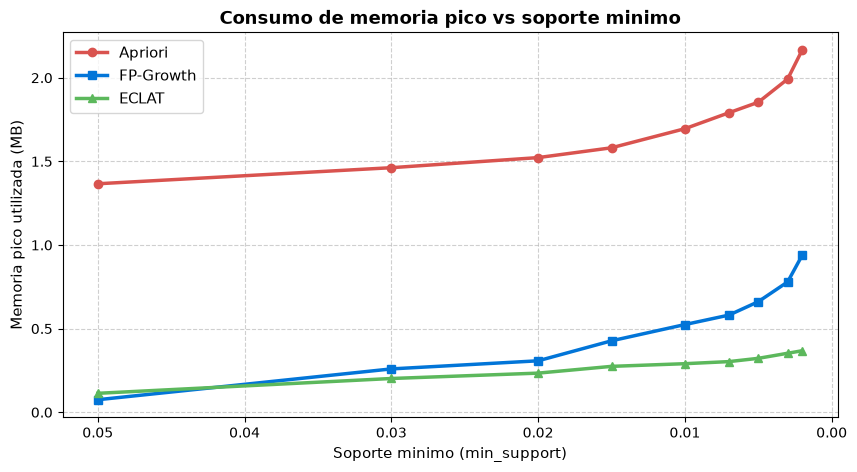

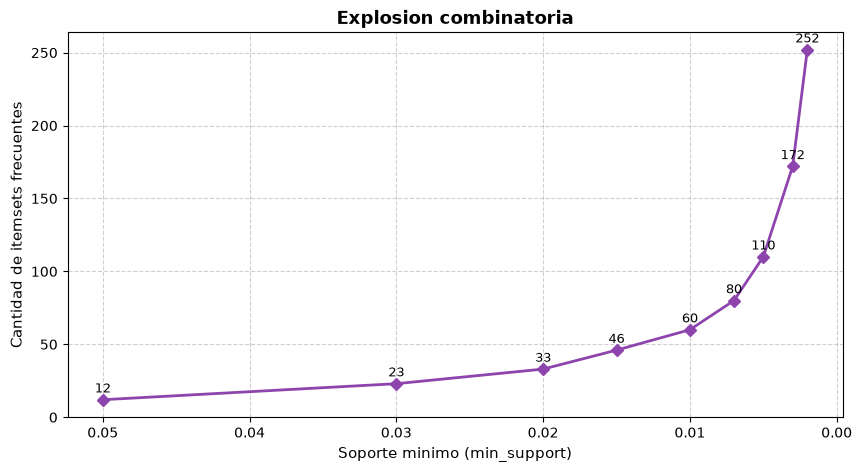

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    bench_df["Support"],
    bench_df["Time_Apriori_s"],
    marker="o",
    linewidth=2,
    label="Apriori",
    color="#d9534f",
)
axes[0].plot(
    bench_df["Support"],
    bench_df["Time_FPGrowth_s"],
    marker="s",
    linewidth=2,
    label="FP-Growth",
    color="#0275d8",
)
axes[0].plot(
    bench_df["Support"],
    bench_df["Time_ECLAT_s"],
    marker="^",
    linewidth=2,
    label="ECLAT",
    color="#5cb85c",
)
axes[0].set_title(
    "Tiempo de ejecucion vs soporte minimo (lineal)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Soporte minimo (min_support)")
axes[0].set_ylabel("Tiempo de ejecucion (segundos)")
axes[0].invert_xaxis()
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(
    bench_df["Support"],
    bench_df["Time_Apriori_s"],
    marker="o",
    linewidth=2,
    label="Apriori",
    color="#d9534f",
)
axes[1].plot(
    bench_df["Support"],
    bench_df["Time_FPGrowth_s"],
    marker="s",
    linewidth=2,
    label="FP-Growth",
    color="#0275d8",
)
axes[1].plot(
    bench_df["Support"],
    bench_df["Time_ECLAT_s"],
    marker="^",
    linewidth=2,
    label="ECLAT",
    color="#5cb85c",
)
axes[1].set_yscale("log")
axes[1].set_title(
    "Tiempo de ejecucion vs soporte minimo (escala log)", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Soporte minimo (min_support)")
axes[1].set_ylabel("Tiempo (segundos, log)")
axes[1].invert_xaxis()
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.show()
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(
    bench_df["Support"],
    bench_df["Mem_Apriori_MB"],
    marker="o",
    linewidth=2.5,
    label="Apriori",
    color="#d9534f",
)
plt.plot(
    bench_df["Support"],
    bench_df["Mem_FPGrowth_MB"],
    marker="s",
    linewidth=2.5,
    label="FP-Growth",
    color="#0275d8",
)
plt.plot(
    bench_df["Support"],
    bench_df["Mem_ECLAT_MB"],
    marker="^",
    linewidth=2.5,
    label="ECLAT",
    color="#5cb85c",
)
plt.title("Consumo de memoria pico vs soporte minimo", fontsize=13, fontweight="bold")
plt.xlabel("Soporte minimo (min_support)", fontsize=11)
plt.ylabel("Memoria pico utilizada (MB)", fontsize=11)
plt.gca().invert_xaxis()
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show(block=False)
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(
    bench_df["Support"], bench_df["Itemsets"], marker="D", linewidth=2, color="#8e44ad"
)
plt.title(
    "Explosion combinatoria",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Soporte minimo (min_support)", fontsize=11)
plt.ylabel("Cantidad de itemsets frecuentes", fontsize=11)
plt.gca().invert_xaxis()
for i, txt in enumerate(bench_df["Itemsets"]):
    plt.annotate(
        str(txt),
        (bench_df["Support"][i], bench_df["Itemsets"][i] + 5),
        fontsize=9,
        ha="center",
    )
plt.grid(True, linestyle="--", alpha=0.6)

plt.show(block=False)
plt.close()

## 5. Generacion de reglas de asociacion y analisis 

 support  confidence  itemsets  total_rules  useful_rules  high_lift_rules
   0.030        0.10        23            9             5                0
   0.030        0.15        23            7             4                0
   0.030        0.20        23            6             4                0
   0.030        0.25        23            6             4                0
   0.030        0.30        23            5             4                0
   0.030        0.40        23            4             4                0
   0.030        0.50        23            4             4                0
   0.030        0.60        23            0             0                0
   0.020        0.10        33           18            12                2
   0.020        0.15        33           16            11                2
   0.020        0.20        33           13            10                1
   0.020        0.25        33           11             9                0
   0.020        0.30     

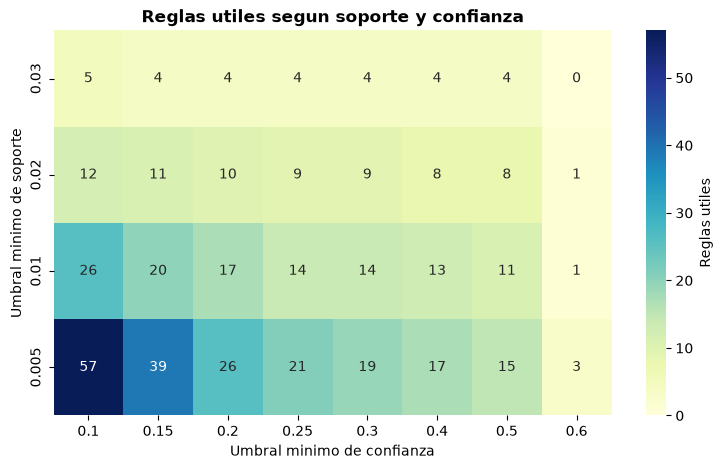

In [ ]:
grid_supports = [0.03, 0.02, 0.01, 0.005]
grid_confidences = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]

grid_results = []
for sup in grid_supports:
    fi = fpgrowth(df_ohe, min_support=sup, use_colnames=True)
    for conf in grid_confidences:
        if len(fi) > 0:
            r_c = association_rules(fi, metric="confidence", min_threshold=conf)
            tot_r = len(r_c)
            useful_r = (r_c["lift"] > 1.0).sum() if tot_r > 0 else 0
            high_lift_r = (r_c["lift"] > 1.5).sum() if tot_r > 0 else 0
        else:
            tot_r, useful_r, high_lift_r = 0, 0, 0
        grid_results.append(
            {
                "support": sup,
                "confidence": conf,
                "itemsets": len(fi),
                "total_rules": tot_r,
                "useful_rules": useful_r,
                "high_lift_rules": high_lift_r,
            }
        )

grid_df = pd.DataFrame(grid_results)
print(grid_df.to_string(index=False))

pivot_useful = grid_df.pivot(
    index="support", columns="confidence", values="useful_rules"
)
plt.figure(figsize=(9, 5))
sns.heatmap(
    pivot_useful,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    cbar_kws={"label": "Reglas utiles"},
)
plt.title(
    "Reglas utiles segun soporte y confianza",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Umbral minimo de confianza")
plt.ylabel("Umbral minimo de soporte")
plt.gca().invert_yaxis()

plt.show()
plt.close()


def run_apriori_pipeline(s, c):
    _, rules = efficient_apriori.apriori(
        transactions_list, min_support=s, min_confidence=c
    )
    return rules


def run_fpgrowth_pipeline(s, c):
    fi = fpgrowth(df_ohe, min_support=s, use_colnames=True)
    return association_rules(fi, metric="confidence", min_threshold=c)


def run_eclat_pipeline(s, c):
    fi = eclat_mining(
        tidsets_global, min_support=s, total_transactions=len(transactions_list)
    )
    return association_rules(fi, metric="confidence", min_threshold=c)


pipeline_benchmark = []
pipelines = [
    ("Apriori", run_apriori_pipeline),
    ("FP-Growth", run_fpgrowth_pipeline),
    ("ECLAT", run_eclat_pipeline),
]

for name, p_func in pipelines:
    tracemalloc.start()
    t0 = time.perf_counter()
    p_res = p_func(0.01, 0.20)
    p_time = time.perf_counter() - t0
    _, p_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    pipeline_benchmark.append(
        {
            "Pipeline": name,
            "Time_s": p_time,
            "Peak_Memory_MB": p_peak / (1024 * 1024),
            "Rules_Count": len(p_res),
        }
    )

pipe_df = pd.DataFrame(pipeline_benchmark)
print(pipe_df.to_string(index=False))

## 6. Analisis y evaluacion de las reglas
Metricas de evaluacion de una regla $X \to Y$:
- Soporte: $P(X \cup Y)$
- Confianza: $P(Y|X) = \frac{P(X \cup Y)}{P(X)}$
- Lift: $\frac{P(X \cup Y)}{P(X)P(Y)}$, vale 1 si $X$ e $Y$ son independientes (Brin et al., 1997)
- Leverage: $P(X \cup Y) - P(X)P(Y)$ (Piatetsky-Shapiro, 1991)
- Conviction: $\frac{1 - P(Y)}{1 - Conf(X \to Y)}$, como el lift pero dirigida (Brin et al., 1997)

Calculamos la media de cada metrica en las reglas de cada celda de la rejilla de la Seccion 5.

 support  confidence  rules  mean_support  mean_confidence  mean_lift  mean_leverage  mean_conviction
   0.030        0.10      9        0.0569           0.3569     0.9149        -0.0164           0.9871
   0.030        0.15      7        0.0582           0.4277     0.9157        -0.0191           0.9881
   0.030        0.20      6        0.0528           0.4676     0.9729        -0.0110           1.0149
   0.030        0.25      6        0.0528           0.4676     0.9729        -0.0110           1.0149
   0.030        0.30      5        0.0453           0.5061     1.0530         0.0003           1.0746
   0.030        0.40      4        0.0441           0.5452     1.1344         0.0051           1.1436
   0.030        0.50      4        0.0441           0.5452     1.1344         0.0051           1.1436
   0.030        0.60      0           NaN              NaN        NaN            NaN              NaN
   0.020        0.10     18        0.0413           0.3685     1.0252        -0.00

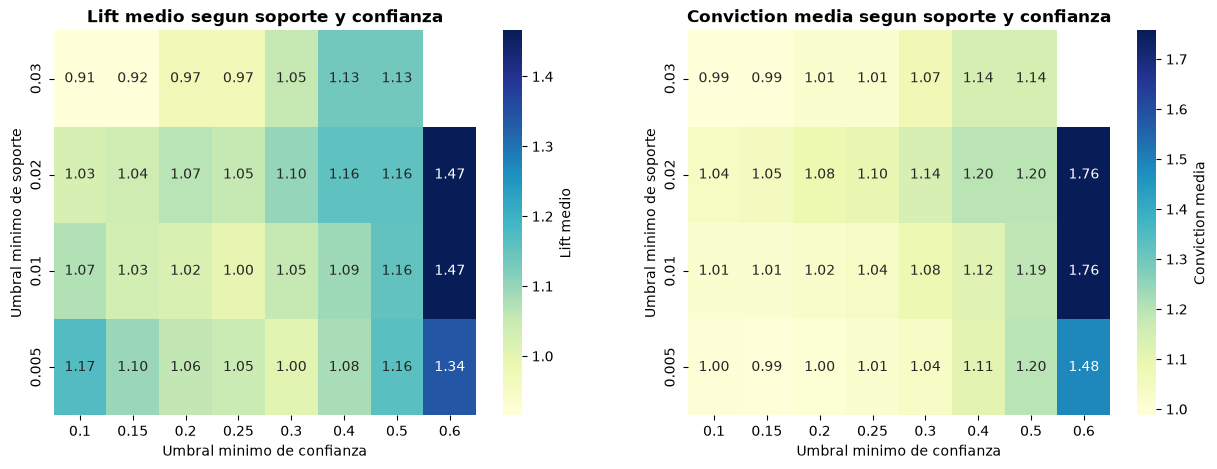

In [ ]:
quality_results = []
for sup in grid_supports:
    fi = fpgrowth(df_ohe, min_support=sup, use_colnames=True)
    for conf in grid_confidences:
        r_c = association_rules(fi, metric="confidence", min_threshold=conf)
        quality_results.append(
            {
                "support": sup,
                "confidence": conf,
                "rules": len(r_c),
                "mean_support": r_c["support"].mean(),
                "mean_confidence": r_c["confidence"].mean(),
                "mean_lift": r_c["lift"].mean(),
                "mean_leverage": r_c["leverage"].mean(),
                "mean_conviction": r_c["conviction"].mean(),
            }
        )

quality_df = pd.DataFrame(quality_results)
print(quality_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric, label in zip(
    axes, ["mean_lift", "mean_conviction"], ["Lift medio", "Conviction media"]
):
    sns.heatmap(
        quality_df.pivot(index="support", columns="confidence", values=metric),
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        ax=ax,
        cbar_kws={"label": label},
    )
    ax.set_title(f"{label} segun soporte y confianza", fontsize=12, fontweight="bold")
    ax.set_xlabel("Umbral minimo de confianza")
    ax.set_ylabel("Umbral minimo de soporte")
    ax.invert_yaxis()

plt.show()
plt.close()

### 6.1 Reglas elegidas
Como vemos, con confianza 0.10 el lift medio sube al bajar el soporte (de 0.91 con 0.03 a 1.17 con 0.005): las asociaciones mas fuertes estan entre productos poco frecuentes.
Al subir la confianza sube la conviction media, pero las reglas se reducen a X -> Coffee: el cafe esta en el 48.1% de las cestas y con confianza >= 0.40 todas las reglas acaban en Coffee.
Ademas, con confianza baja se mantienen las reglas con lift < 1, que tambien nos interesan.

Por eso usamos min_support = 0.005 y min_confidence = 0.10, la celda con mas reglas utiles (57 de 101 con lift > 1) y con mas reglas de lift > 1.5 (20).
Las reglas se sacan con FP-Growth y comprobamos que Apriori y ECLAT dan exactamente las mismas.

In [ ]:
base_frequent_itemsets = fpgrowth(df_ohe, min_support=0.005, use_colnames=True)
rules = association_rules(
    base_frequent_itemsets, metric="confidence", min_threshold=0.10
)
rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules["rule_str"] = rules["antecedents_str"] + " -> " + rules["consequents_str"]

fi_ap_check = apriori_itemsets(transactions_list, min_support=0.005)
fi_ec_check = eclat_mining(
    tidsets_global, min_support=0.005, total_transactions=len(transactions_list)
)
rules_ap_check = association_rules(fi_ap_check, metric="confidence", min_threshold=0.10)
rules_ec_check = association_rules(fi_ec_check, metric="confidence", min_threshold=0.10)

key_fp = set(zip(rules["antecedents"], rules["consequents"]))
key_ap = set(zip(rules_ap_check["antecedents"], rules_ap_check["consequents"]))
key_ec = set(zip(rules_ec_check["antecedents"], rules_ec_check["consequents"]))
print(
    f"Reglas generadas | FP-Growth: {len(rules)} | Apriori: {len(rules_ap_check)} | ECLAT: {len(rules_ec_check)}"
)
print(f"Mismas reglas en los 3 algoritmos: {key_fp == key_ap == key_ec}")

Reglas generadas | FP-Growth: 101 | Apriori: 101 | ECLAT: 101
Mismas reglas en los 3 algoritmos: True


### 6.2 Visualizacion de las reglas

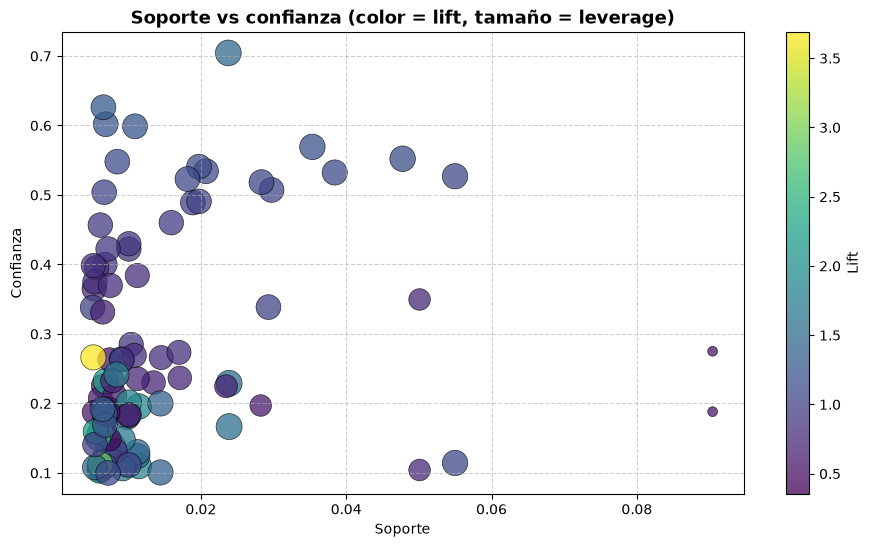

In [ ]:
norm_leverage = (rules["leverage"] - rules["leverage"].min()) / (
    rules["leverage"].max() - rules["leverage"].min()
)

plt.figure(figsize=(11, 6))
scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    s=50 + norm_leverage * 300,
    cmap="viridis",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.5,
)
plt.colorbar(scatter, label="Lift")
plt.title(
    "Soporte vs confianza (color = lift, tamaño = leverage)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Soporte")
plt.ylabel("Confianza")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()
plt.close()

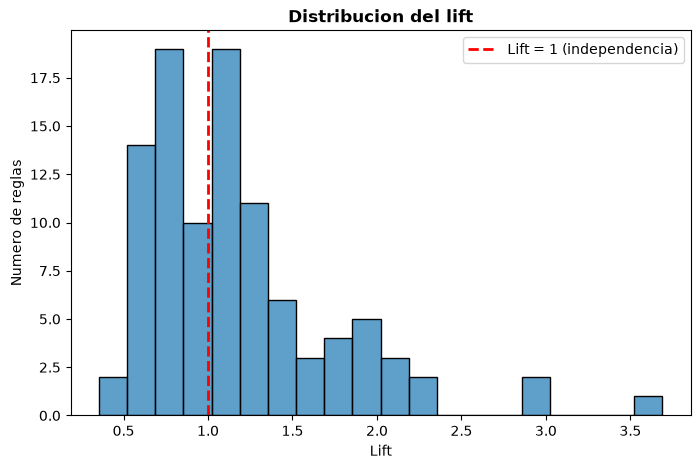

In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(rules["lift"], bins=20, color="#2980b9", edgecolor="black", ax=ax)
ax.axvline(
    1.0, color="red", linestyle="--", linewidth=2, label="Lift = 1 (independencia)"
)
ax.set_title("Distribucion del lift", fontsize=12, fontweight="bold")
ax.set_xlabel("Lift")
ax.set_ylabel("Numero de reglas")
ax.legend()

plt.show()
plt.close()

## 7. Reglas clave
Vemos las reglas desde tres puntos de vista:
1. Mayor lift: productos que se compran juntos mucho mas de lo esperado.
2. Mayor confianza: compras mas predecibles a partir del antecedente.
3. Lift < 1: productos que se compran juntos menos de lo esperado.

In [ ]:
cols_show = [
    "rule_str",
    "antecedent support",
    "consequent support",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction",
]

top_lift = rules.sort_values("lift", ascending=False).head(10)
top_conf = rules.sort_values("confidence", ascending=False).head(10)
neg_rules = rules[rules["lift"] < 1].sort_values("lift").head(10)

print("Top 10 reglas por lift")
print(top_lift[cols_show].to_string(index=False))
print("\nTop 10 reglas por confianza")
print(top_conf[cols_show].to_string(index=False))
print("\nTop 10 reglas con lift < 1")
print(neg_rules[cols_show].to_string(index=False))

Top 10 reglas por lift
                     rule_str  antecedent support  consequent support  support  confidence     lift  leverage  conviction
             Coke -> Sandwich            0.019529            0.072172 0.005201    0.266304 3.689882  0.003791    1.264596
             Cookies -> Juice            0.054659            0.038739 0.006156    0.112621 2.907174  0.004038    1.083259
             Juice -> Cookies            0.038739            0.054659 0.006156    0.158904 2.907174  0.004038    1.123939
Coffee, Hot chocolate -> Cake            0.029718            0.104330 0.006899    0.232143 2.225076  0.003798    1.166454
             Soup -> Sandwich            0.034600            0.072172 0.005519    0.159509 2.210141  0.003022    1.103913
Cake, Coffee -> Hot chocolate            0.054978            0.058586 0.006899    0.125483 2.141843  0.003678    1.076495
Hot chocolate -> Cake, Coffee            0.058586            0.054978 0.006899    0.117754 2.141843  0.003678    1.071155
 

### 7.1 Grafo de reglas
Grafo dirigido (antecedente -> consecuente) con las reglas de lift > 1.5. El grosor de la flecha es proporcional al lift.

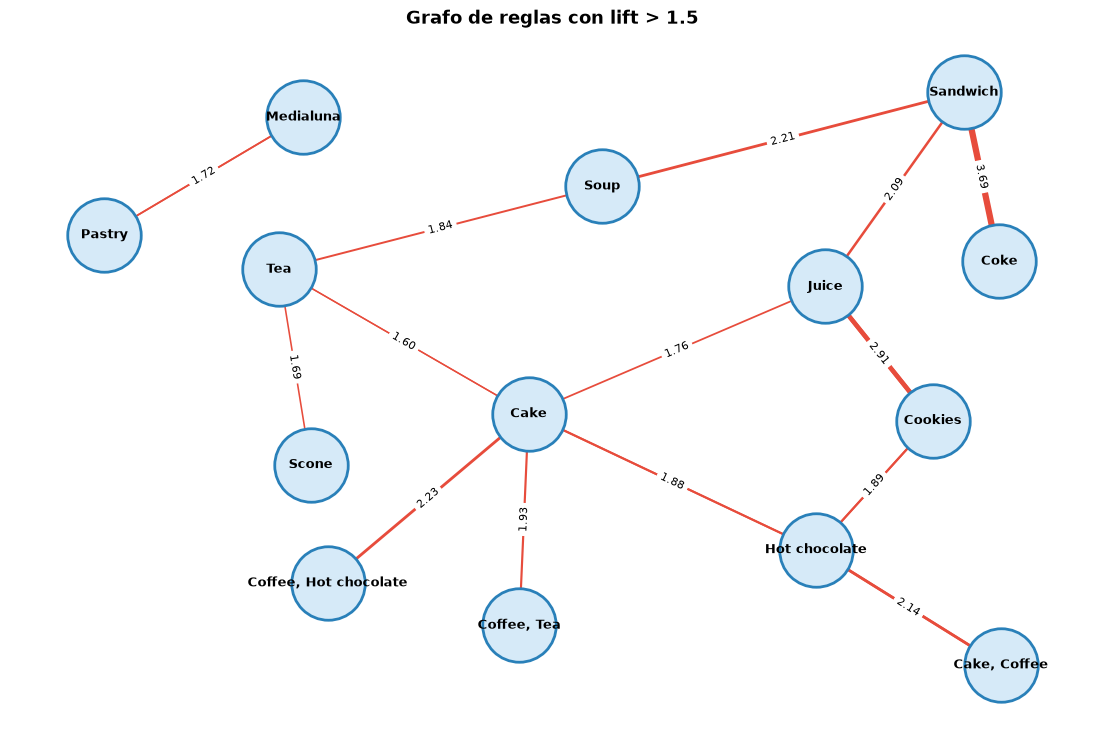

In [ ]:
level = 1.5
G = nx.DiGraph()
for _, r in rules[rules["lift"] > level].sort_values("rule_str").iterrows():
    G.add_edge(r["antecedents_str"], r["consequents_str"], weight=r["lift"])

lifts = [w for _, _, w in G.edges(data="weight")]
widths = [1 + (w - min(lifts)) / (max(lifts) - min(lifts)) * 3.5 for w in lifts]

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, k=0.9, seed=399)
nx.draw_networkx_nodes(
    G, pos, node_size=2800, node_color="#d6eaf8", edgecolors="#2980b9", linewidths=2
)
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    edge_color="#e74c3c",
    width=widths,
)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={(u, v): f"{w:.2f}" for u, v, w in G.edges(data="weight")},
    font_size=8,
)
plt.title(f"Grafo de reglas con lift > {level}", fontsize=13, fontweight="bold")
plt.axis("off")

plt.show()
plt.close()

## 8. Discusion y conclusiones
### 8.1 Interpretacion de las reglas
- Menu de almuerzo: `Coke -> Sandwich` (lift 3.69) y `Soup -> Sandwich` (lift 2.21). Se puede ofrecer un menu de sandwich con bebida o sopa y poner los sandwiches junto a las bebidas.
- Galletas: `Cookies <-> Juice` (lift 2.91) y `Cookies <-> Hot chocolate` (lift 1.89). Conviene colocarlos juntos, pensando en niños y familias.
- El cafe como producto ancla: `Toast` (confianza 70.4%), `Salad` (62.6%), `Spanish Brunch` (59.9%), `Medialuna` (56.9%) y `Pastry` (55.2%) llevan cafe en mas de la mitad de los casos. Esta confianza esta inflada porque el cafe esta en el 48.1% de las cestas, su lift es moderado (1.15-1.47).
- Pan y cafe: `Bread <-> Coffee` tiene lift 0.57, se compran juntos menos de lo esperado. Son dos tipos de cliente distintos: el que compra pan para casa y el que toma un cafe con bolleria. No tiene sentido promocionarlos juntos.

### 8.2 Comparacion con la literatura
- Apriori (Agrawal y Srikant, 1994): genera candidatos nivel a nivel ($L_{k-1} \times L_{k-1} \to C_k$). `efficient_apriori` cuenta el soporte intersectando los indices de transaccion de cada item, sin recorrer todas las transacciones en cada nivel. Es el que mas memoria usa en todos los umbrales (de ~1.4 MB a ~2.2 MB).
- FP-Growth (Han et al., 2000): comprime los datos en un FP-Tree y no genera candidatos. Usa poca memoria (< 1 MB) pero es el mas lento y su tiempo apenas cambia con el soporte: domina el coste fijo de mlxtend (validar el DataFrame y recorrer fila a fila las transacciones para construir el arbol).
- ECLAT (Zaki et al., 1997): usa representacion vertical (TID-sets) y busqueda en profundidad. Es el mas rapido en todos los umbrales y el de menor memoria salvo con soporte 0.05, gracias a las intersecciones de conjuntos de Python.

### 8.3 Conclusiones
Los 3 algoritmos obtienen los mismos itemsets y reglas, asi que solo cambia la eficiencia: ECLAT es el mas rapido y ligero, Apriori el que mas memoria usa y FP-Growth el mas lento.
Con 9.422 transacciones, 90 productos y como maximo 252 itemsets frecuentes no se llega a la explosion combinatoria que la literatura atribuye a Apriori, por lo que las diferencias vienen mas de cada implementacion que del propio algoritmo.